In [ ]:
!pip install sqlite

ERROR: Could not find a version that satisfies the requirement sqlite (from versions: none)
ERROR: No matching distribution found for sqlite


In [ ]:
!pip install -qU langchain_community

In [ ]:
!pip install -qU langchain_groq

In [ ]:
import sqlite3
conn=sqlite3.connect('langchain.db')
cursor=conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS orders(
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_name TEXT NOT NULL,
    product_name TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REALB NOT NULL,
    total REAL NOT NULL)
    """)
cursor.execute("""
INSERT INTO orders(customer_name,product_name,quantity,price,total)VALUES
("ABC","Laptop",1,1000.00,1000.00),
("PQR","Smartphone",2,500.00,1000.00),
("XYZ","Tablet",3,200.00,600.00)
""")

conn.commit()


In [ ]:

cursor.execute("""
SELECT * FROM orders
""")
rows=cursor.fetchall()
for row in rows:
  print(row)
conn.close()

(1, 'ABC', 'Laptop', 1, 1000.0, 1000.0)
(2, 'PQR', 'Smartphone', 2, 500.0, 1000.0)
(3, 'XYZ', 'Tablet', 3, 200.0, 600.0)
(4, 'ABC', 'Laptop', 1, 1000.0, 1000.0)
(5, 'PQR', 'Smartphone', 2, 500.0, 1000.0)
(6, 'XYZ', 'Tablet', 3, 200.0, 600.0)
(7, 'ABC', 'Laptop', 1, 1000.0, 1000.0)
(8, 'PQR', 'Smartphone', 2, 500.0, 1000.0)
(9, 'XYZ', 'Tablet', 3, 200.0, 600.0)


#SQL DATABASE AGENT

In [ ]:
from langchain_community.utilities.sql_database import SQLDatabase
sql_db = SQLDatabase.from_uri("sqlite:///langchain.db")
print(sql_db.table_info)


CREATE TABLE orders (
	id INTEGER, 
	customer_name TEXT NOT NULL, 
	product_name TEXT NOT NULL, 
	quantity INTEGER NOT NULL, 
	price REAL NOT NULL, 
	total REAL NOT NULL, 
	PRIMARY KEY (id)
)

/*
3 rows from orders table:
id	customer_name	product_name	quantity	price	total
1	ABC	Laptop	1	1000.0	1000.0
2	PQR	Smartphone	2	500.0	1000.0
3	XYZ	Tablet	3	200.0	600.0
*/


In [ ]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
from langchain_groq import ChatGroq
import os
from google.colab import userdata
os.environ["GROQ_API_KEY"] =  userdata.get('GROQ_API_KEY')

llm_groq = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
    )

toolkit = SQLDatabaseToolkit(db=sql_db,llm=llm_groq)

In [ ]:
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7eee5288b750>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7eee5288b750>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7eee5288b750>),
 QuerySQLCheckerTool(description='Use this tool to double check

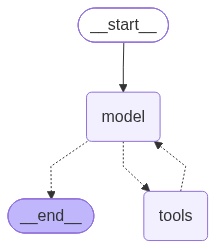

In [ ]:
from langchain.agents import create_agent

agent = create_agent(llm_groq, toolkit.get_tools())
agent

In [ ]:
query = "How much sales we made for Smartphone?"

events = agent.stream(
    {"messages":[("user",query)]},
    stream_mode="values",
)
for event in events:
  event["messages"][-1].pretty_print()


================================ Human Message =================================

How much sales we made for Smartphone?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (71qbr92ht)
 Call ID: 71qbr92ht
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

orders
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (mdncp2bhx)
 Call ID: mdncp2bhx
  Args:
    table_names: orders
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE orders (
	id INTEGER, 
	customer_name TEXT NOT NULL, 
	product_name TEXT NOT NULL, 
	quantity INTEGER NOT NULL, 
	price REAL NOT NULL, 
	total REAL NOT NULL, 
	PRIMARY KEY (id)
)

/*
3 rows from orders table:
id	customer_name	product_name	quantity	price	total
1	ABC	Laptop	1	1000.0	1000.0
2	PQR	Smartphone	2	500.0	1000.0
3